# A股 Alpha因子 研究

## 针对全部A股

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from typing import List, Optional

def rowwise_residuals(df1: pd.DataFrame, df2: pd.DataFrame) -> pd.DataFrame:
    """
    对 df1 的每一行 y，用 df2 同一行作为 X 做 OLS 回归，输出残差组成的新 DataFrame
    """
    assert df1.shape == df2.shape, "df1 和 df2 的 shape 必须一致"
    
    residuals = []
    index = df1.index
    columns = df1.columns

    for i in range(len(df1)):
        y = df1.iloc[i].values
        X = df2.iloc[i].values

        # 忽略全 NaN 或零方差的情况
        if pd.isna(y).all() or pd.isna(X).all() or np.std(X) == 0:
            residuals.append([np.nan] * len(y))
            continue
        
        # 注意 Nan 的处理
        y = y - np.nanmean(y)
        y = np.nan_to_num(y, nan=0.0)

        # 构造 DataFrame for回归
        X = X - np.nanmean(X)
        X = np.nan_to_num(X, nan=0.0)
        model = sm.OLS(y, X)
        results = model.fit()

        # 残差 = y - y_hat
        eps = results.resid
        residuals.append(eps)

    res_df = pd.DataFrame(residuals, index=index, columns=columns)
    return res_df

# 定义市值因子生成函数
def gen_factors(market_cap: pd.DataFrame, daily_ret: pd.DataFrame, universe: Optional[pd.DataFrame]=None):
    factors = {}
    # 原始市值
    factors['market_cap'] = market_cap
    # 市值对数
    factors['log_market_cap'] = np.log(market_cap)
    # 标准化市值
    std_mc = (market_cap - market_cap.mean(axis=1).values.reshape(-1, 1)) / market_cap.std(axis=1).values.reshape(-1, 1)
    # 标准化市值的平方
    factors['std_market_cap_sq'] = std_mc ** 2
    # 波动率
    factors['vol'] = daily_ret.rolling(250).std()
    # 市值对数残差（对市值回归市值对数，取残差）
    factors['cap_logcap_resid'] = rowwise_residuals(market_cap, np.log(market_cap))
    # 波动率对市值的正交
    factors['vol_logcap_resid'] = rowwise_residuals(factors['vol'].loc[market_cap.index], np.log(market_cap))
    # 动量因子
    factors['Momentum_1M'] = daily_ret.rolling(20).sum()
    factors['Momentum_3M'] = daily_ret.rolling(20 * 3).sum()
    factors['Momentum_6M'] = daily_ret.rolling(20 * 6).sum()
    factors['Momentum_12M'] = daily_ret.rolling(20 * 12).sum()
    factors['Momentum_1M_Max'] = daily_ret.rolling(20).max()
    factors['Momentum_12M_1M'] = daily_ret.rolling(20 * 12).sum() -  daily_ret.rolling(20).sum()

    factors["ResidualRisk_1M"] = (daily_ret - daily_ret.rolling(20).mean()).rolling(20).std()

    if not universe is None:
        for f, v in factors:
            v = v.loc[universe.index]
            factors[f] = v * universe
    return factors


In [8]:
# 读取、整理数据
adj_close = pd.read_csv('s_dq_adjclose_v2.csv', index_col=0)
market_cap = pd.read_csv('market_cap.csv', index_col=0)
universe_lst = list(market_cap.loc[:, market_cap.max(axis=0) > 0].columns)
universe_lst = [x for x in universe_lst if x not in ['000022.SZ', '000043.SZ', '600003.SH', '000522.SZ']]

daily_ret = np.log(adj_close.shift(-1) / adj_close)
daily_ret = daily_ret.loc[:, universe_lst].fillna(0)

ts = market_cap.index
adj_close  = adj_close.loc[ts]
adj_close = adj_close.ffill()
monthly_ret = np.log(adj_close.shift(-1) / adj_close)
monthly_ret = monthly_ret.loc[:, universe_lst]
market_cap = market_cap.loc[:, universe_lst]
size_factors = gen_factors(market_cap, daily_ret, ts)

In [9]:
from typing import Tuple, Dict
import statsmodels.api as sm
from scipy.stats import spearmanr



def calc_ic(factor: pd.DataFrame, monthly_ret: pd.DataFrame, cal_factor_return = False, use_spearman=True) -> Tuple[Dict, pd.Series] :
    ic = {}
    fr = {}
    ts = factor.index.intersection(monthly_ret.index)
    ts = ts[:-1]  # 排除最后一天的因子

    for day in ts:
        f_i = factor.loc[day].dropna()
        r_i = monthly_ret.loc[day].dropna()
        common_assets = f_i.index.intersection(r_i.index)

        if len(common_assets) == 0:
            # print("factor value all nan in", day)
            # ic[day] = np.nan
            fr[day] = np.nan
            continue

        if f_i.std() == 0:
            # print("same factor value in", day)
            ic[day] = np.nan
            fr[day] = np.nan
            continue

        f_i = f_i.loc[common_assets]
        r_i = r_i.loc[common_assets]

        # 计算 IC（信息系数，即因子值和未来收益的 Spearman 相关系数）
        if use_spearman:
            ic[day], _ = spearmanr(f_i, r_i)
        else:
            ic[day] = np.corrcoef(f_i, r_i)[0, 1]

        # 横截面回归，r_i = alpha + beta * f_i + epsilon，beta 就是因子收益
        # 做这个回归需要对因子进行归一化, 只有这样得出的回归系数才有真实的意义
        # 因为这个操作比较耗时，初筛时可以选择不做，得出的结论和 IC 差不多
        if cal_factor_return:
            f_i = (f_i - f_i.mean()) / f_i.std()
            X = sm.add_constant(f_i)  # 添加截距项
            model = sm.OLS(r_i, X)
            results = model.fit()
            fr[day] = results.params[f_i.name] if f_i.name in results.params else results.params[1]
        else:
            fr[day] = 0

    ic_series = pd.Series(ic)
    fr_series = pd.Series(fr)
    n = fr_series.count()
    mean = fr_series.mean()
    std = fr_series.std(ddof=1)

    summary = {
        "IC": ic_series.mean(),
        "IC_positive": sum(ic_series > 0) / len(ic_series),
        "IR": ic_series.mean() / ic_series.std() if ic_series.std() != 0 else np.nan,
        "Factor Mean Return": fr_series.mean(),
        "Factor Return tstat":  mean / (std / np.sqrt(n)) if std > 0 else np.nan
    }

    return summary, fr_series

res_all = {}
factor_ret_all = {}
for factor_name, factor_value in size_factors.items():
    try:
        summary, fr_series = calc_ic(factor_value, monthly_ret, cal_factor_return=True, use_spearman=True)
        res_all[factor_name] = summary
        factor_ret_all[factor_name] = fr_series
    except:
        raise Exception(f"[{factor_name}] Error")
    
res_all = pd.DataFrame(res_all).T
res_all

,IC,IC_positive,IR,Factor Mean Return,Factor Return tstat
market_cap,-0.051589,0.389222,-0.333080,-0.000674,-1.060914
log_market_cap,-0.051589,0.389222,-0.333080,-0.004947,-3.732184
std_market_cap_sq,0.041057,0.688623,0.553154,-0.000012,-0.041923
vol,-0.062912,0.348387,-0.353420,-0.006530,-4.125259
cap_logcap_resid,0.052241,0.664671,0.400229,0.002275,6.004747
vol_logcap_resid,-0.065953,0.335484,-0.396989,-0.006880,-4.570936
Momentum_1M,-0.003988,0.526946,-0.027488,0.002068,1.660265
Momentum_3M,-0.030316,0.463415,-0.207174,-0.001580,-1.250345
Momentum_6M,-0.025567,0.459627,-0.175139,-0.001940,-1.474002
Momentum_12M,-0.024268,0.429487,-0.166224,-0.002298,-1.659855


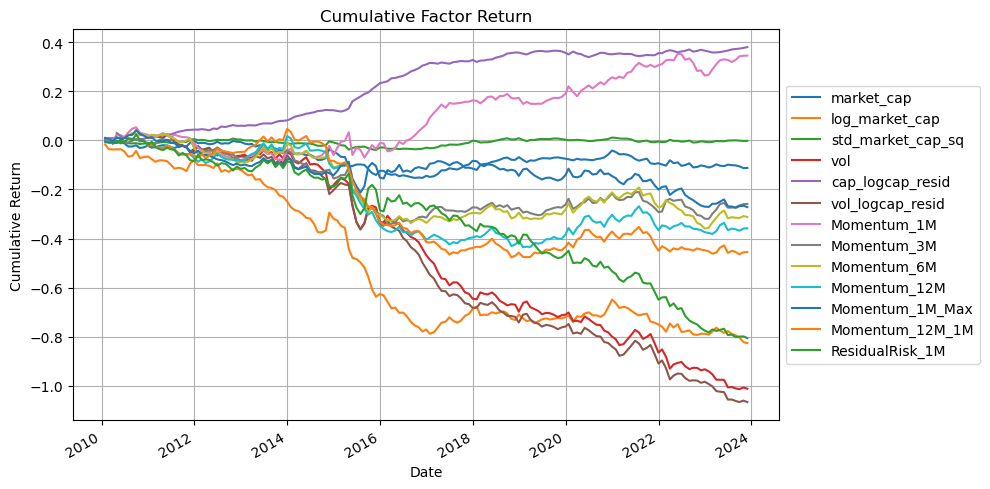

In [10]:
def convert_index_to_datetime(df: pd.DataFrame|pd.Series):
    index = df.index
    # 判断是否是形如 20250101 的整数或字符串格式
    if all(isinstance(i, (int, str)) and len(str(i)) == 8 for i in index):
        try:
            df.index = pd.to_datetime(index, format="%Y%m%d")
        except Exception as e:
            print("转换失败：", e)
    else:
        print("索引不是 yyyymmdd 格式，未做转换")
    return df

factor_ret_all = pd.DataFrame(factor_ret_all)
factor_ret_all = convert_index_to_datetime(factor_ret_all)
factor_ret_all.cumsum().plot(figsize=(10, 5))

import matplotlib.pyplot as plt

# 设置 legend 在右侧图外
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.0, 0.5)  # (x=1.0 为图外右侧，y=0.5 为垂直居中)
)

plt.title("Cumulative Factor Return")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)

plt.tight_layout()  # 防止标签遮挡
plt.show()


## 针对中证800的Universe

In [ ]:
import pandas as pd
import numpy as np


universe = pd.read_csv('universe_800.csv', index_col=0).loc[ts]

# 读取、整理数据
adj_close = pd.read_csv('s_dq_adjclose_v2.csv', index_col=0)
market_cap = pd.read_csv('market_cap.csv', index_col=0)
market_cap = market_cap*universe
universe_lst = list(market_cap.loc[:, market_cap.max(axis=0) > 0].columns)
# universe_lst = [x for x in universe_lst if x not in ['000022.SZ', '000043.SZ', '600003.SH', '000522.SZ']]
ts = market_cap.index
universe = universe.loc[ts, universe_lst]

print("universe shape:", universe.shape)

daily_ret = np.log(adj_close/ adj_close.shift(1))
daily_ret = daily_ret.loc[:, universe_lst]

adj_close  = adj_close.loc[ts]
adj_close = adj_close.ffill()
monthly_ret = np.log(adj_close.shift(-1) / adj_close)
monthly_ret = monthly_ret.loc[:, universe_lst]
market_cap = market_cap.loc[:, universe_lst]
size_factors = gen_factors(market_cap, daily_ret, universe)
res_all = {}
factor_ret_all = {}
for factor_name, factor_value in size_factors.items():
    try:
        summary, fr_series = calc_ic(factor_value, monthly_ret, cal_factor_return=True, use_spearman=True)
        res_all[factor_name] = summary
        factor_ret_all[factor_name] = fr_series
    except:
        raise Exception(f"[{factor_name}] Error")
    
res_all = pd.DataFrame(res_all).T
res_all

universe shape: (168, 1625)


,IC,IC_positive,IR,Factor Mean Return,Factor Return tstat
market_cap,-0.009004,0.502994,-0.053184,0.000267,0.355962
log_market_cap,-0.009004,0.502994,-0.053184,-0.000636,-0.509902
std_market_cap_sq,0.017755,0.562874,0.242408,0.000322,0.775248
vol,-0.058341,0.387097,-0.306670,-0.003521,-2.412538
cap_logcap_resid,0.013887,0.538922,0.142250,0.000632,2.186259
vol_logcap_resid,-0.056450,0.374194,-0.317059,-0.003370,-2.433248
Momentum_1M,0.013723,0.592814,0.090892,0.002864,2.271426
Momentum_3M,-0.008641,0.542683,-0.054151,0.000751,0.591524
Momentum_6M,-0.003298,0.534161,-0.019872,0.000679,0.489558
Momentum_12M,0.005766,0.525641,0.033632,0.001268,0.900983


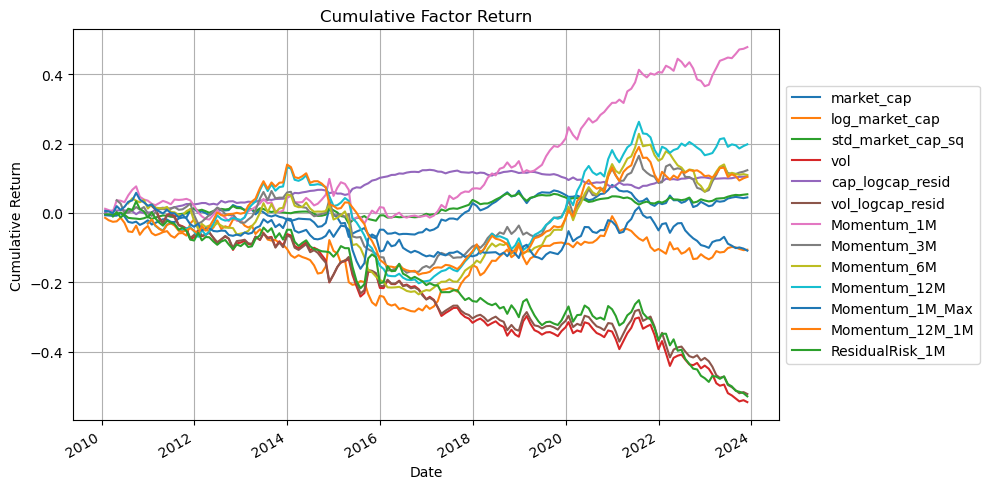

In [12]:
factor_ret_all = pd.DataFrame(factor_ret_all)
factor_ret_all = convert_index_to_datetime(factor_ret_all)
factor_ret_all.cumsum().plot(figsize=(10, 5))

import matplotlib.pyplot as plt

# 设置 legend 在右侧图外
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.0, 0.5)  # (x=1.0 为图外右侧，y=0.5 为垂直居中)
)

plt.title("Cumulative Factor Return")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)

plt.tight_layout()  # 防止标签遮挡
plt.show()